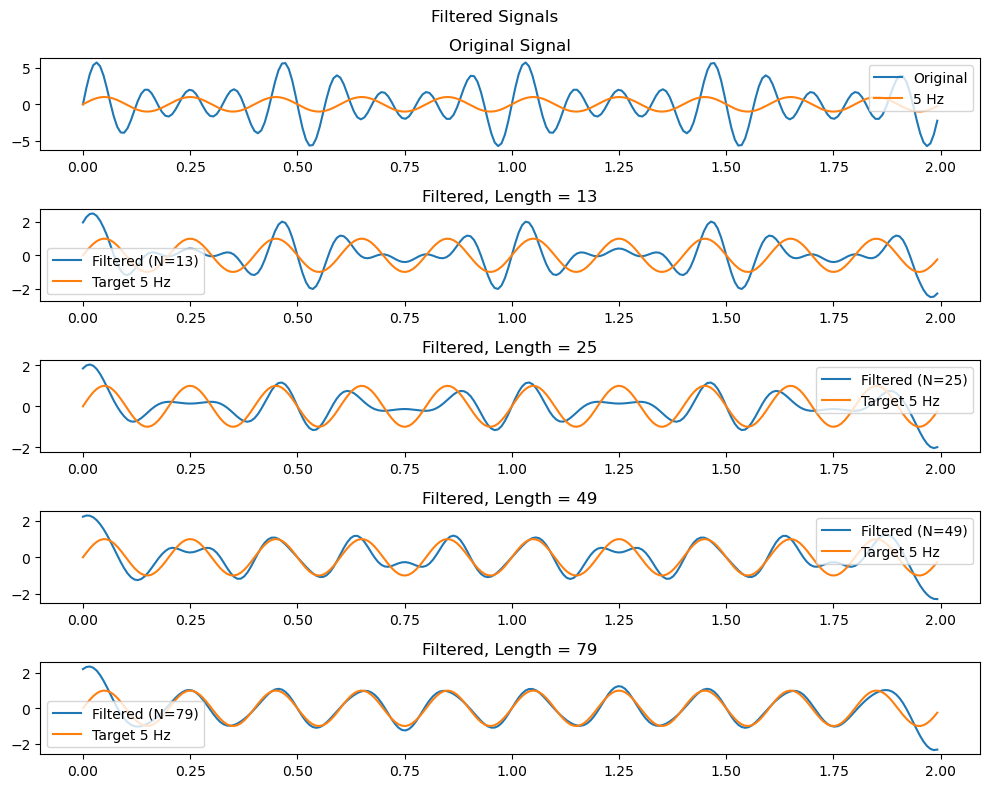

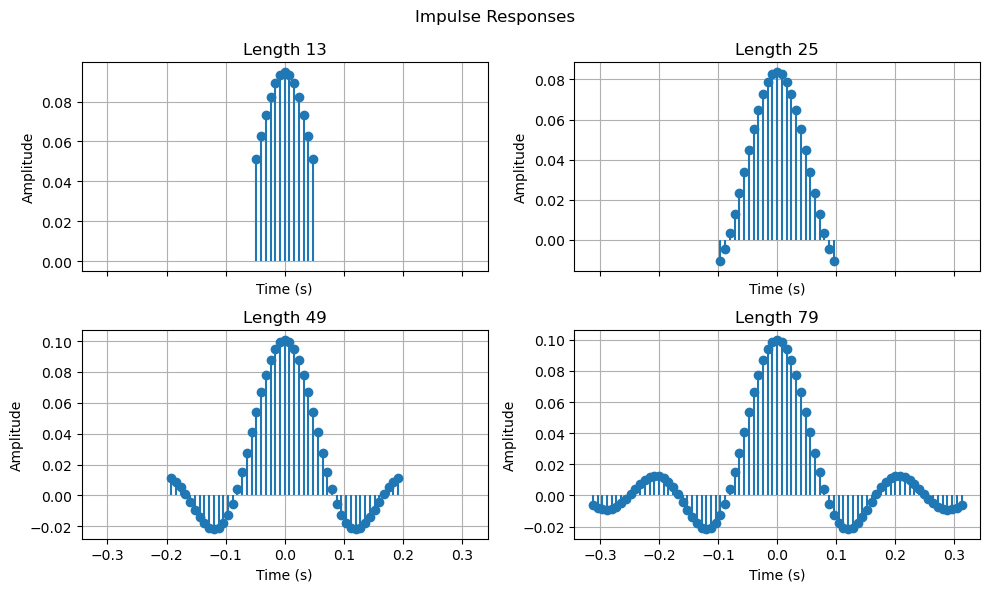

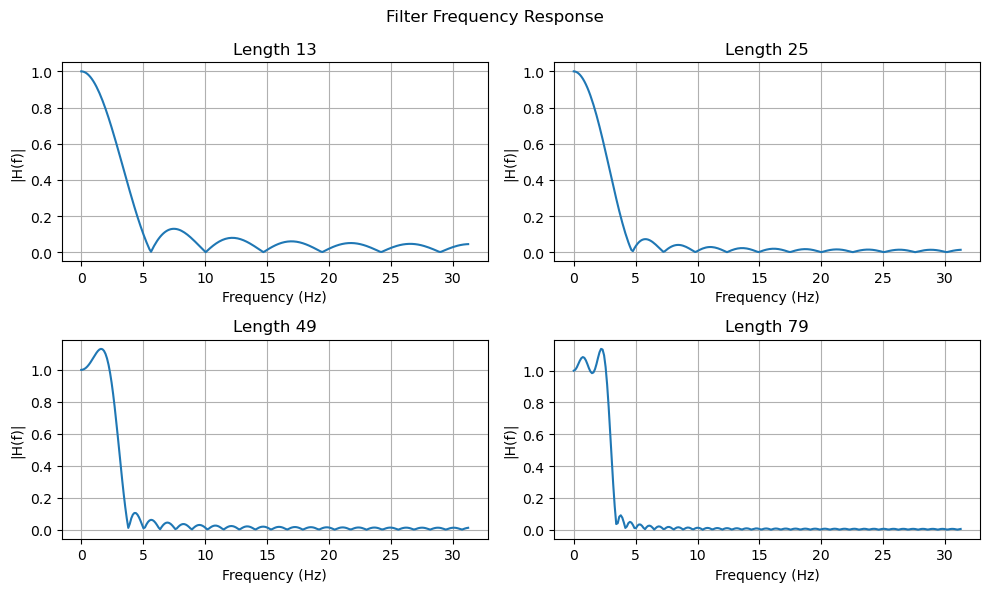

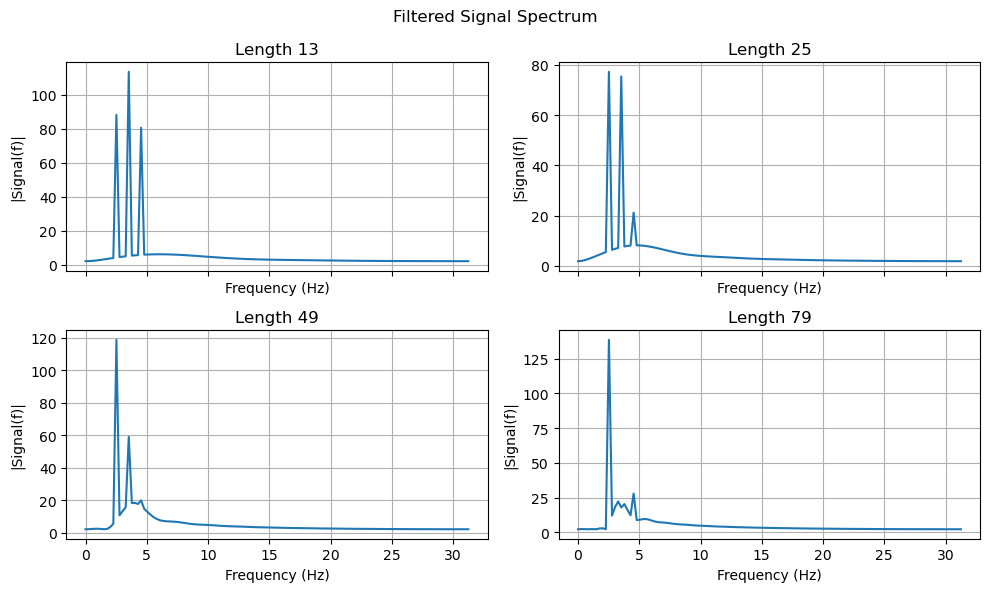

In [22]:
# ======================
# Low Pass Filter
# ======================


import numpy as np
import matplotlib.pyplot as plt

# ======================
# Parameter sinyal
# ======================
t = np.arange(0, 2, 0.008)  # 0–2 detik dengan interval 8 ms
fs = 1 / (2*0.008)  # frekuensi nyquist

# Komponen frekuensi
f1, f2, f3 = 5, 7, 9
a1, a2, a3 = 1, 2, 3

# Sinyal gabungan dan komponen 5 Hz
sinyal = a1*np.sin(2*np.pi*f1*t) + a2*np.sin(2*np.pi*f2*t) + a3*np.sin(2*np.pi*f3*t)
sinyal5 = a1*np.sin(2*np.pi*f1*t)

# ======================
# Desain filter FIR (rectangular window LPF)
# ======================
fc = 6  # Hz
N = np.array([13, 25, 49, 79])
h = []

for n in N:
    hi = 2 * fc * np.sinc((2 * fc * (np.arange(n) - ((n - 1) / 2)) * 0.008))
    hi /= np.sum(hi)
    h.append(hi)

# list FIR
hn = h  

# ======================
# Konvolusi sinyal dengan masing-masing filter
# ======================
signal_o = []
for i in range(len(N)):
    signal_oi = np.convolve(sinyal, hn[i], mode='full')
    signal_o.append(signal_oi)

# potong hasil konvolusi agar panjang sama dengan sinyal asli
signal_result = []
for i in range(len(N)):
    half = int((N[i]-1)/2)
    signal_r = signal_o[i][half:len(sinyal)+half]
    signal_result.append(signal_r)
signal_result = np.array(signal_result)

# ======================
# Plot sinyal hasil filter
# ======================
fig, sf = plt.subplots(5, figsize=(10, 8))
sf[0].plot(t, sinyal, label='Original')
sf[0].plot(t, sinyal5, label='5 Hz')
sf[0].set_title("Original Signal")
sf[0].legend()

for i in range(len(N)):
    sf[i+1].plot(t, signal_result[i], label=f'Filtered (N={N[i]})')
    sf[i+1].plot(t, sinyal5, label='Target 5 Hz')
    sf[i+1].legend()
    sf[i+1].set_title(f'Filtered, Length = {N[i]}')

fig.suptitle('Filtered Signals')
plt.tight_layout()
plt.show()

# ======================
# Plot Impulse Response
# ======================
fig, im = plt.subplots(2, 2, figsize=(10, 6), sharex=True)
for idx, ax in enumerate(im.flat):
    ax.stem((np.arange(N[idx]) - ((N[idx]-1)/2)) * 0.008, hn[idx], basefmt=" ")
    ax.set_title(f'Length {N[idx]}')
    ax.grid(True)
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Amplitude')

fig.suptitle('Impulse Responses')
plt.tight_layout()
plt.show()

# ======================
# Frekuensi Respon Filter
# ======================
HW = []
for hi in hn:
    hwni = np.fft.fft(hi, n=512)  # zero-padding agar halus
    HW.append(np.abs(hwni[:256]))  # hanya separuh (positif)
HW = np.array(HW)

f = np.linspace(0, fs/2, 256)

fig, fim = plt.subplots(2, 2, figsize=(10, 6))
for idx, ax in enumerate(fim.flat):
    ax.plot(f, HW[idx])
    ax.set_title(f'Length {N[idx]}')
    ax.grid(True)
    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel('|H(f)|')

fig.suptitle('Filter Frequency Response')
plt.tight_layout()
plt.show()

# ======================
# FFT dari hasil sinyal terfilter
# ======================
signal_RW = []
for s in signal_result:
    signal_OWi = np.fft.fft(s)
    signal_RW.append(np.abs(signal_OWi[:len(s)//2]))
signal_RW = np.array(signal_RW)

f_sig = np.linspace(0, fs/2, len(signal_RW[0]))

fig, sw = plt.subplots(2, 2, figsize=(10, 6), sharex=True)
for idx, ax in enumerate(sw.flat):
    ax.plot(f_sig, signal_RW[idx])
    ax.set_title(f'Length {N[idx]}')
    ax.grid(True)
    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel('|Signal(f)|')

fig.suptitle('Filtered Signal Spectrum')
plt.tight_layout()
plt.show()


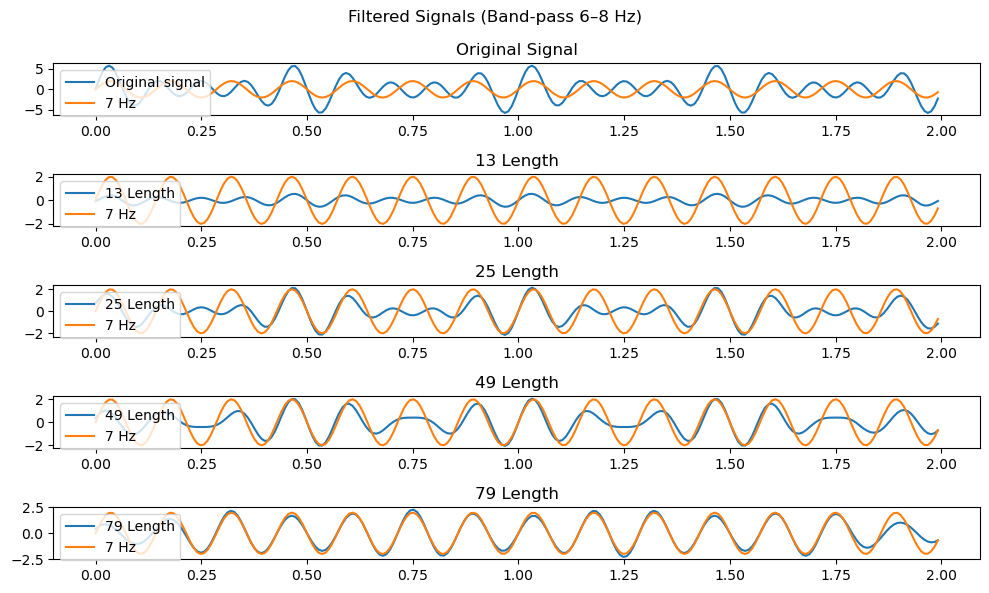

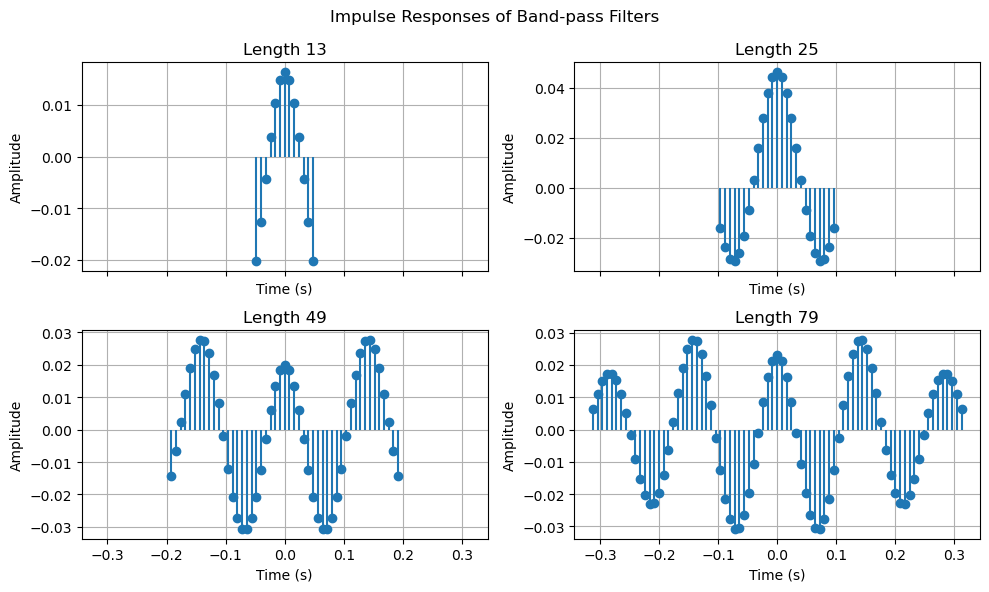

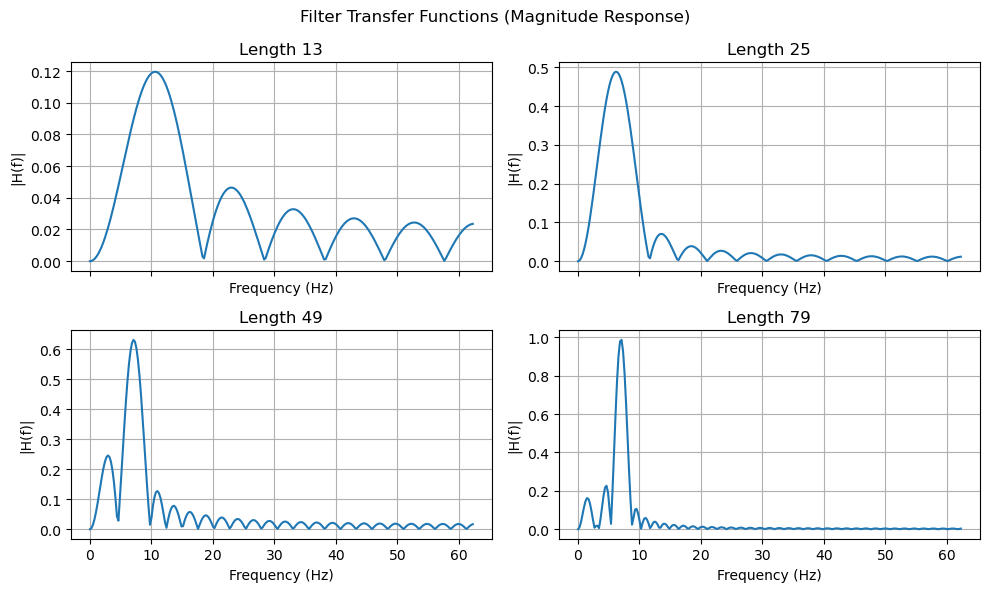

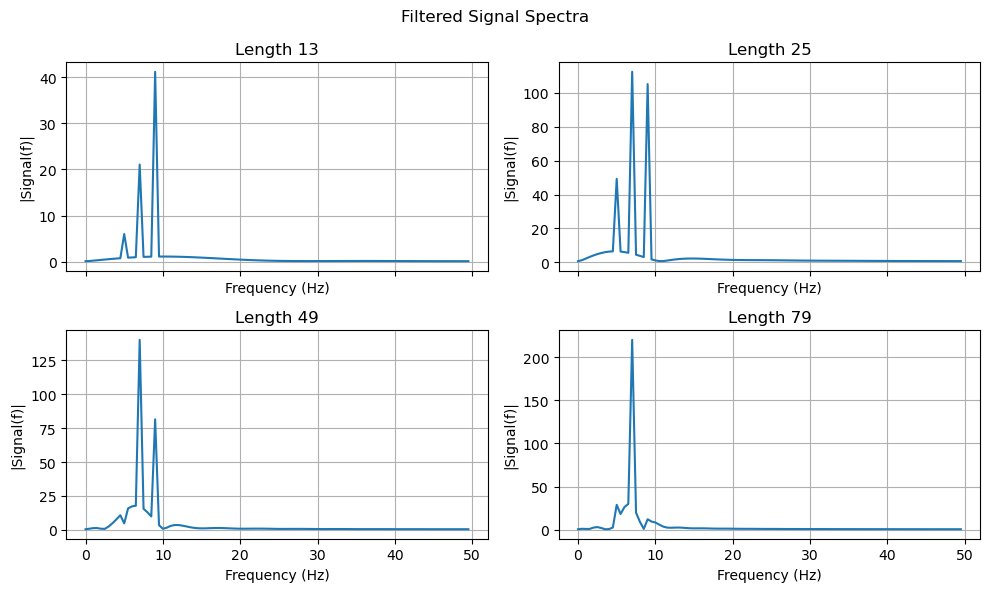

In [23]:
# ======================
# Band Pass Filter
# ======================

import numpy as np
import matplotlib.pyplot as plt

# ======================
# Parameter sinyal
# ======================
t = np.arange(0, 2, 0.008)  # 0–2 detik, Δt = 8 ms
fs = 1 / 0.008              # sampling frequency (125 Hz)

# Komponen frekuensi dan amplitudo
f1, f2, f3 = 5, 7, 9
a1, a2, a3 = 1, 2, 3

# Sinyal gabungan dan komponen 7 Hz
sinyal = a1*np.sin(2*np.pi*f1*t) + a2*np.sin(2*np.pi*f2*t) + a3*np.sin(2*np.pi*f3*t)
sinyal7 = a2*np.sin(2*np.pi*f2*t)

# ======================
# Desain FIR Band-Pass Filter (6–8 Hz)
# ======================
fl, fh = 6, 8
N = np.array([13, 25, 49, 79])
h = []

for n in N:
    t_idx = np.arange(n) - (n - 1) / 2
    h_low = 2*fl*np.sinc(2*fl*t_idx*0.008)
    h_low /= np.sum(h_low)
    h_high = 2*fh*np.sinc(2*fh*t_idx*0.008)
    h_high /= np.sum(h_high)
    hi = h_high - h_low  # band-pass
    h.append(hi)

# ======================
# Konvolusi sinyal dengan filter
# ======================
signal_result = []
for i, n in enumerate(N):
    y_full = np.convolve(sinyal, h[i], mode='full')
    offset = (n - 1) // 2
    y_trimmed = y_full[offset:offset + len(sinyal)]  # potong biar panjang sama
    signal_result.append(y_trimmed)

signal_result = np.array(signal_result)

# ======================
# Plot sinyal hasil filter
# ======================
fig, sf = plt.subplots(5, figsize=(10, 6))
sf[0].plot(t, sinyal, label='Original signal')
sf[0].plot(t, sinyal7, label='7 Hz')
sf[0].legend()
sf[0].set_title("Original Signal")

titles = ["13 Length", "25 Length", "49 Length", "79 Length"]
for i in range(4):
    sf[i+1].plot(t, signal_result[i], label=titles[i])
    sf[i+1].plot(t, sinyal7, label='7 Hz')
    sf[i+1].set_title(titles[i])
    sf[i+1].legend()

fig.suptitle('Filtered Signals (Band-pass 6–8 Hz)')
plt.tight_layout()
plt.show()

# ======================
# Plot impulse response
# ======================
fig, im = plt.subplots(2, 2, figsize=(10, 6), sharex=True)
for i, ax in enumerate(im.flat):
    n = N[i]
    ax.stem((np.arange(n) - (n - 1) / 2)*0.008, h[i], basefmt=" ")
    ax.set_title(f"Length {n}")
    ax.grid(True)
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Amplitude')

fig.suptitle('Impulse Responses of Band-pass Filters')
plt.tight_layout()
plt.show()

# ======================
# Filter Frequency Response
# ======================
HW = []
for hi in h:
    HW.append(np.fft.fft(hi, 512))
HW = np.array(HW)
f = np.fft.fftfreq(512, d=0.008)

fig, fim = plt.subplots(2, 2, figsize=(10, 6), sharex=True)
for i, ax in enumerate(fim.flat):
    ax.plot(f[:256], np.abs(HW[i][:256]))
    ax.set_title(f"Length {N[i]}")
    ax.grid(True)
    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel('|H(f)|')

fig.suptitle('Filter Transfer Functions (Magnitude Response)')
plt.tight_layout()
plt.show()

# ======================
# FFT dari sinyal terfilter
# ======================
signal_fft = [np.fft.fft(sig) for sig in signal_result]
signal_fft = np.array(signal_fft)
f = np.fft.fftfreq(len(t), d=0.008)

fig, sw = plt.subplots(2, 2, figsize=(10, 6), sharex=True)
for i, ax in enumerate(sw.flat):
    ax.plot(f[:100], np.abs(signal_fft[i][:100]))
    ax.set_title(f"Length {N[i]}")
    ax.grid(True)
    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel('|Signal(f)|')

fig.suptitle('Filtered Signal Spectra')
plt.tight_layout()
plt.show()


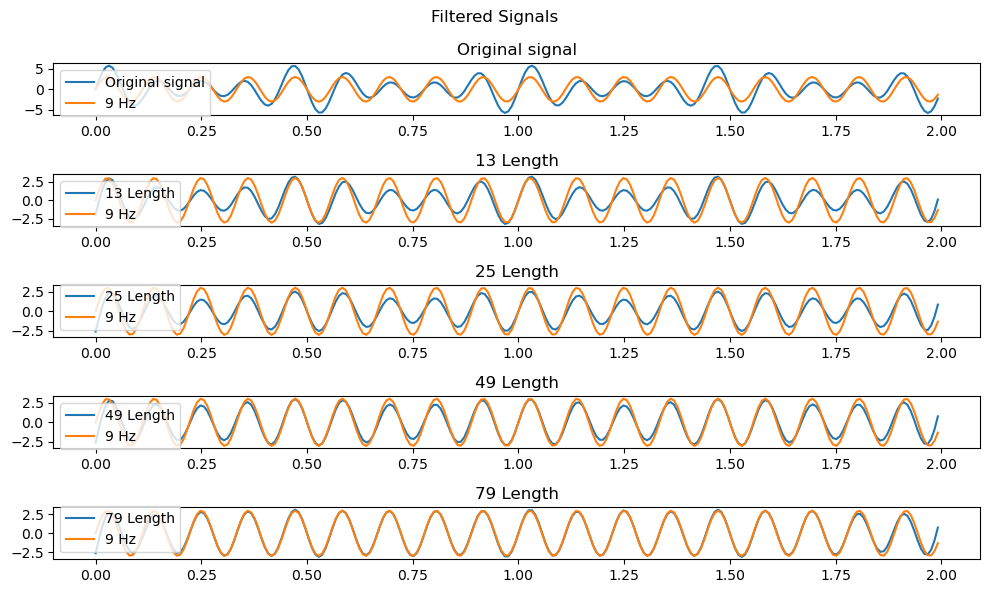

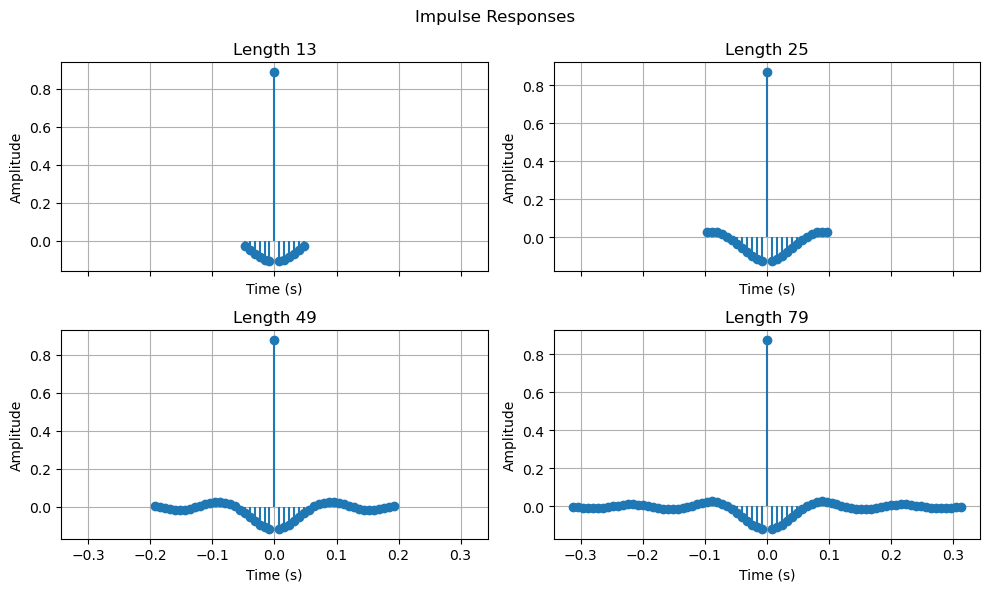

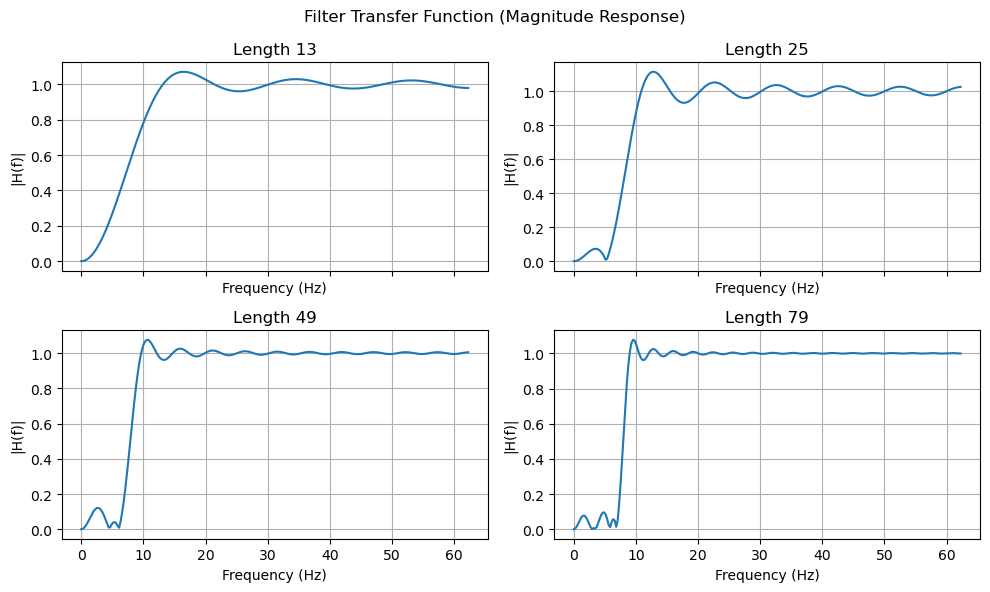

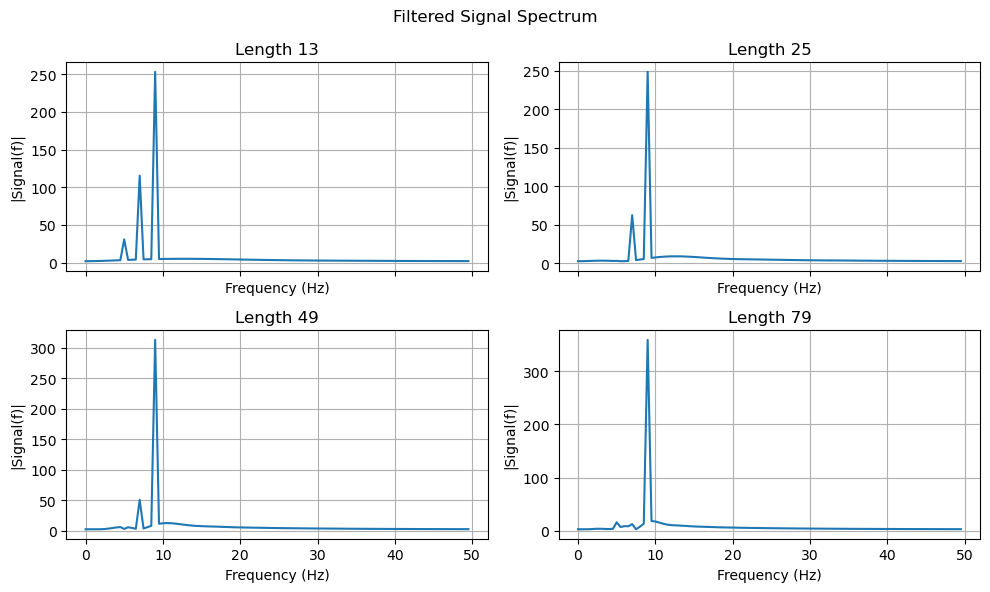

In [24]:
# ======================
# High Pass Filter
# ======================

import numpy as np
import matplotlib.pyplot as plt

# ======================
# Rectangular
# ======================
t = np.arange(0, 2, 0.008)  # waktu (0–2 s) dengan interval 8 ms
fs = 1 / (2 * 0.008)        # frekuensi Nyquist

# Komponen frekuensi
f1, f2, f3 = 5, 7, 9
a1, a2, a3 = 1, 2, 3

# Sinyal gabungan dan komponen 9 Hz
sinyal = a1 * np.sin(2*np.pi*f1*t) + a2 * np.sin(2*np.pi*f2*t) + a3 * np.sin(2*np.pi*f3*t)
sinyal9 = a3 * np.sin(2*np.pi*f3*t)

# ======================
# Desain Finite Filter 
# ======================
fc = 8  # cut-off frequency
N = np.array([13, 25, 49, 79])
h = []

for n in N:
    hi = 2*fc*np.sinc((2*fc*(np.arange(n) - (n-1)/2) * 0.008))
    hi /= np.sum(hi)
    hi *= -1
    hi[(n-1)//2] += 1
    h.append(hi)

# ======================
# Konvolusi sinyal
# ======================
signal_o = []
for i in range(len(N)):
    signal_oi = np.convolve(sinyal, h[i], mode='full')
    signal_o.append(signal_oi)

# Pemotongan hasil konvolusi agar sama panjang dengan sinyal asli
signal_r0 = []
for i in range(len(N)):
    n = N[i]
    offset = (n - 1) // 2
    trimmed = signal_o[i][offset:offset + len(sinyal)]
    signal_r0.append(trimmed)

signal_result = np.array(signal_r0)

# ======================
# Plot sinyal hasil filter
# ======================
fig, sf = plt.subplots(5, figsize=(10, 6))
sf[0].plot(t, sinyal, label='Original signal')
sf[0].plot(t, sinyal9, label='9 Hz')
sf[0].set_title("Original signal")
sf[0].legend()

titles = ["13 Length", "25 Length", "49 Length", "79 Length"]
for i in range(4):
    sf[i+1].plot(t, signal_result[i], label=f"{titles[i]}")
    sf[i+1].plot(t, sinyal9, label='9 Hz')
    sf[i+1].set_title(titles[i])
    sf[i+1].legend()

fig.suptitle('Filtered Signals')
plt.tight_layout()
plt.show()

# ======================
# Plot impulse response
# ======================
fig, im = plt.subplots(2, 2, figsize=(10, 6), sharex=True)
for i, ax in enumerate(im.flat):
    ax.stem((np.arange(N[i]) - (N[i]-1)/2)*0.008, h[i], basefmt=" ")
    ax.set_title(f"Length {N[i]}")
    ax.grid(True)
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Amplitude')

fig.suptitle('Impulse Responses')
plt.tight_layout()
plt.show()

# ======================
# Frekuensi respon filter (FFT)
# ======================
HW = []
for hi in h:
    hwni = np.fft.fft(hi, 512)
    HW.append(hwni)
HW = np.array(HW)

f = np.fft.fftfreq(512, d=0.008)

fig, fim = plt.subplots(2, 2, figsize=(10, 6), sharex=True)
for i, ax in enumerate(fim.flat):
    ax.plot(f[:256], np.abs(HW[i][:256]))
    ax.set_title(f"Length {N[i]}")
    ax.grid(True)
    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel('|H(f)|')

fig.suptitle('Filter Transfer Function (Magnitude Response)')
plt.tight_layout()
plt.show()

# ======================
# FFT hasil sinyal terfilter
# ======================
signal_OW = []
for i in range(len(N)):
    signal_OWi = np.fft.fft(signal_result[i])
    signal_OW.append(signal_OWi)

signal_RW = np.array(signal_OW)
f = np.fft.fftfreq(len(t), d=0.008)

fig, sw = plt.subplots(2, 2, figsize=(10, 6), sharex=True)
for i, ax in enumerate(sw.flat):
    ax.plot(f[:100], np.abs(signal_RW[i][:100]))
    ax.set_title(f"Length {N[i]}")
    ax.grid(True)
    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel('|Signal(f)|')

fig.suptitle('Filtered Signal Spectrum')
plt.tight_layout()
plt.show()
